In [ ]:
from google.colab import files
uploaded = files.upload()

Saving RUL_FD001.txt to RUL_FD001 (1).txt
Saving test_FD001.txt to test_FD001 (1).txt
Saving train_FD001.txt to train_FD001 (1).txt



Gradient Boosting RESULTS
------------------------------
RMSE : 41.37
MAE  : 29.90

Random Forest RESULTS
------------------------------
RMSE : 41.52
MAE  : 29.70


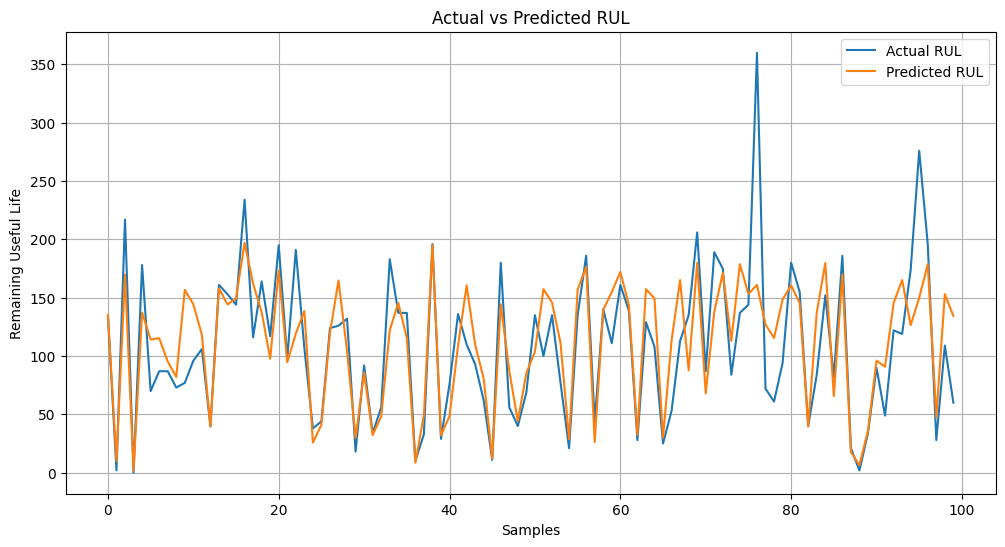

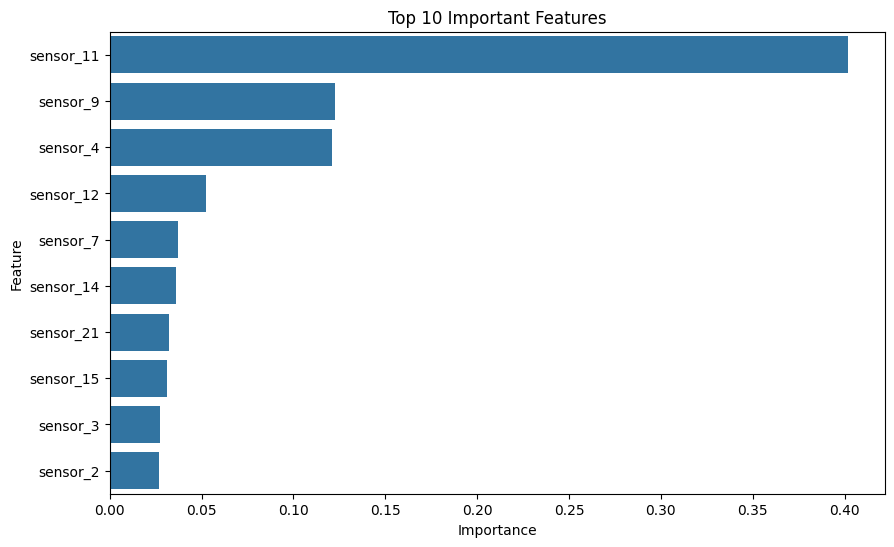

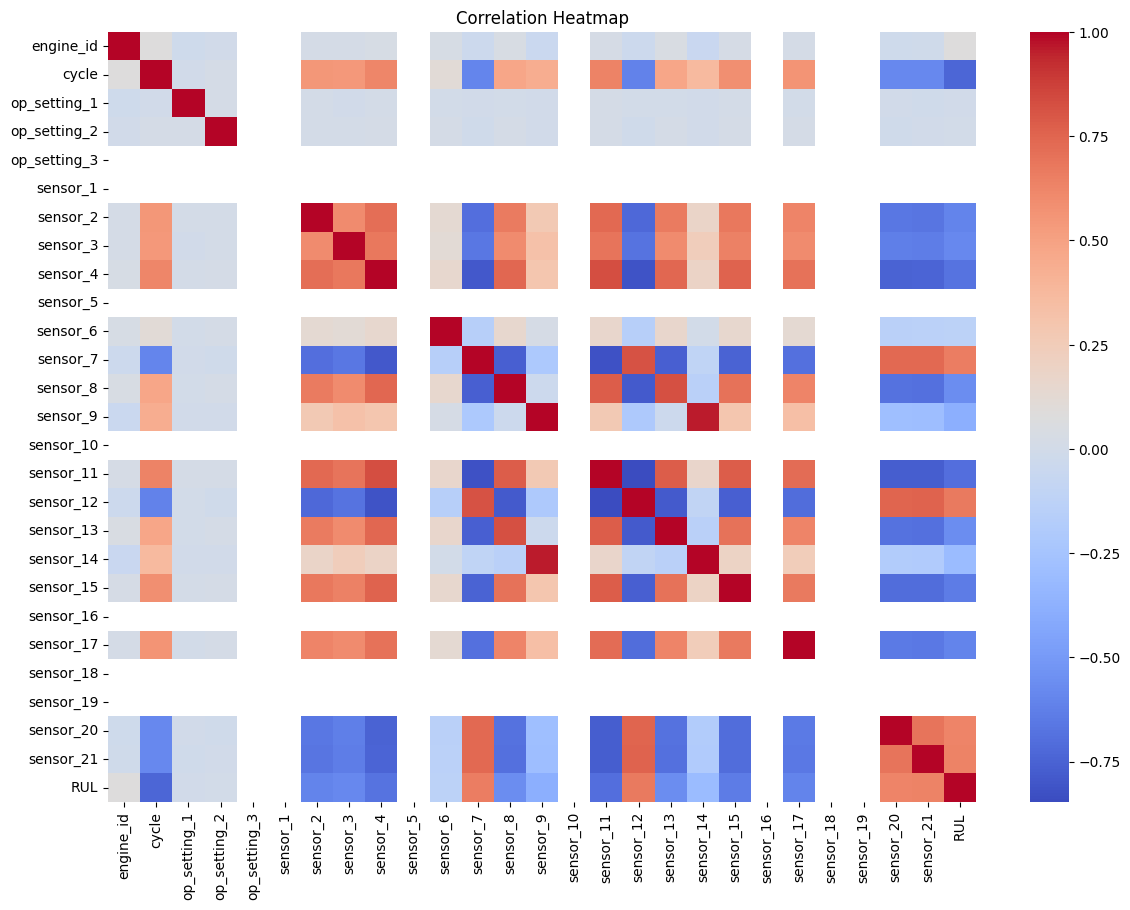


PROJECT EXECUTED SUCCESSFULLY


In [ ]:
# =========================================
# AI-BASED AIRCRAFT ENGINE FAILURE PREDICTION
# =========================================

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================================
# LOAD DATASET
# =========================================

# COLUMN NAMES
columns = ['engine_id', 'cycle']

for i in range(1, 4):
    columns.append(f'op_setting_{i}')

for i in range(1, 22):
    columns.append(f'sensor_{i}')

# READ TRAIN DATA
train_df = pd.read_csv(
    'train_FD001.txt',
    sep=r'\s+',
    header=None
)

train_df.columns = columns

# READ TEST DATA
test_df = pd.read_csv(
    'test_FD001.txt',
    sep=r'\s+',
    header=None
)

test_df.columns = columns

# READ RUL VALUES
rul_df = pd.read_csv(
    'RUL_FD001.txt',
    header=None
)

# =========================================
# GENERATE RUL FOR TRAINING DATA
# =========================================

max_cycle = train_df.groupby('engine_id')['cycle'].max()

train_df['RUL'] = train_df.apply(
    lambda row: max_cycle[row['engine_id']] - row['cycle'],
    axis=1
)

# =========================================
# FEATURE SELECTION
# =========================================

drop_columns = ['engine_id', 'cycle', 'RUL']

X = train_df.drop(columns=drop_columns)
y = train_df['RUL']

# =========================================
# NORMALIZATION
# =========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
# =========================================
# GRADIENT BOOSTING REGRESSOR
# =========================================

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

# =========================================
# RANDOM FOREST MODEL
# =========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# =========================================
# EVALUATION FUNCTION
# =========================================

def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name} RESULTS")
    print("-" * 30)

    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")

# =========================================
# MODEL EVALUATION
# =========================================

evaluate_model(
    'Gradient Boosting',
    y_test,
    gb_predictions
)

evaluate_model(
    'Random Forest',
    y_test,
    rf_predictions
)

# =========================================
# ACTUAL VS PREDICTED GRAPH
# =========================================

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label='Actual RUL'
)

plt.plot(
    rf_predictions[:100],
    label='Predicted RUL'
)

plt.title('Actual vs Predicted RUL')

plt.xlabel('Samples')

plt.ylabel('Remaining Useful Life')

plt.legend()

plt.grid(True)

plt.show()

# =========================================
# FEATURE IMPORTANCE
# =========================================

importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# TOP 10 IMPORTANT FEATURES

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title('Top 10 Important Features')

plt.show()

# =========================================
# CORRELATION HEATMAP
# =========================================

plt.figure(figsize=(14,10))

sns.heatmap(
    train_df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

print("\nPROJECT EXECUTED SUCCESSFULLY")

In [ ]:
import os

print(os.getcwd())
print(os.listdir())
print(os.listdir('/'))
print(os.listdir('/content'))
print(os.listdir('/mnt'))

/content
['.config', 'sample_data']
['tmp', 'root', 'sbin', 'var', 'run', 'libx32', 'media', 'lib64', 'usr', 'srv', 'proc', 'mnt', 'bin', 'etc', 'home', 'sys', 'boot', 'dev', 'lib32', 'opt', 'lib', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']
['.config', 'sample_data']
[]


In [4]:
from google.colab import files

uploaded = files.upload()

Saving train_FD001.txt to train_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving RUL_FD001.txt to RUL_FD001.txt


In [5]:
import os
print(os.listdir())

['.config', 'train_FD001.txt', 'test_FD001.txt', 'RUL_FD001.txt', 'sample_data']


X Shape: (20601, 30, 24)
y Shape: (20601,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,251 (313.48 KB)

 Trainable params: 80,251 (313.48 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - loss: 12723.3516 - mae: 92.5052 - val_loss: 15815.0361 - val_mae: 100.1214
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - loss: 10506.0273 - mae: 82.0743 - val_loss: 13583.8594 - val_mae: 91.0275
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - loss: 8805.6953 - mae: 74.1138 - val_loss: 11782.0264 - val_mae: 83.8232
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - loss: 7508.6855 - mae: 68.1686 - val_loss: 10378.4131 - val_mae: 78.3423
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - loss: 6514.9399 - mae: 63.6694 - val_loss: 9273.6826 - val_mae: 74.1541
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 5784.6611 - mae: 60.4247 - val_loss: 8432.0410 - val_mae: 71.0801
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 5280.9541 - mae: 58.2229 - val_loss: 7801.8071 - val_mae: 68.8844
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 4930.7363 - mae: 56.7393 - val_loss

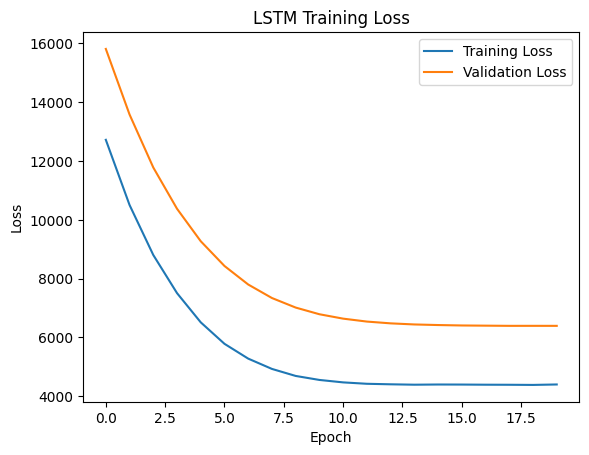

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# -----------------------------------
# Load Dataset
# -----------------------------------

columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

train_df = train_df.iloc[:, :26]
train_df.columns = columns

# -----------------------------------
# Generate RUL
# -----------------------------------

max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

train_df.drop(columns=['max_cycle'], inplace=True)

# -----------------------------------
# Feature Selection
# -----------------------------------

features = train_df.drop(columns=['engine_id', 'cycle', 'RUL'])
target = train_df['RUL']

# -----------------------------------
# Normalize
# -----------------------------------

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# -----------------------------------
# Create Sequences
# -----------------------------------

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(features_scaled)):
    X.append(features_scaled[i-sequence_length:i])
    y.append(target.iloc[i])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# -----------------------------------
# Build LSTM Model
# -----------------------------------

model = Sequential()

model.add(LSTM(100,
               return_sequences=True,
               input_shape=(X.shape[1], X.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# -----------------------------------
# Train Model
# -----------------------------------

history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

# -----------------------------------
# Save Model
# -----------------------------------

model.save("aircraft_engine_lstm.h5")

# -----------------------------------
# Plot Training Loss
# -----------------------------------

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training Loss")

plt.legend()
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

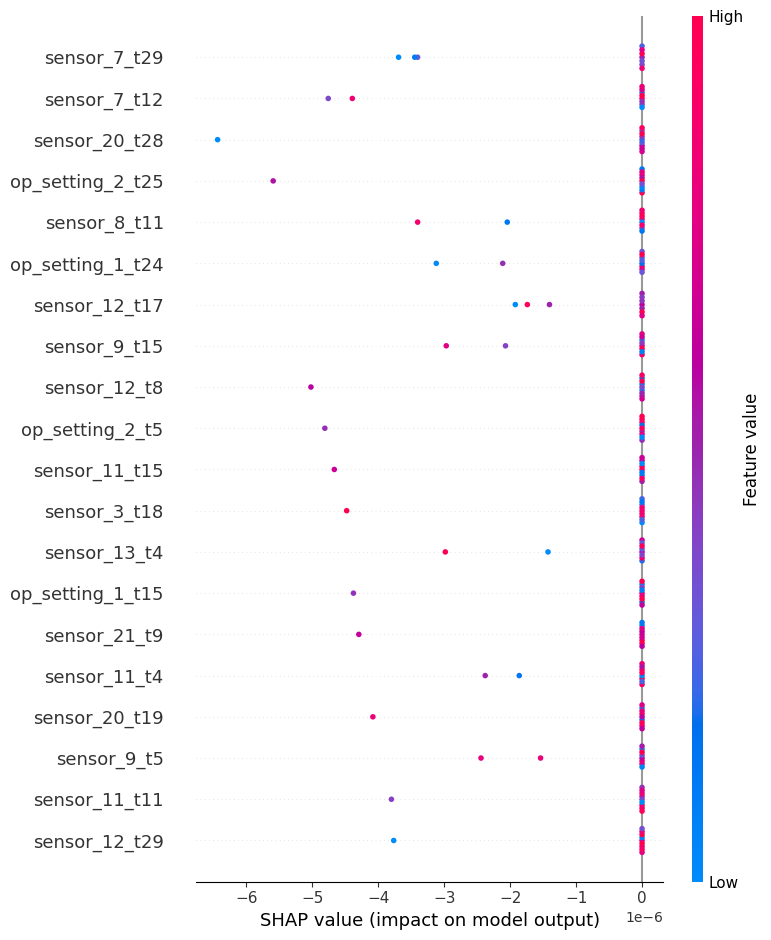

In [7]:
import shap
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# -----------------------------------
# Load Model
# -----------------------------------
model = load_model("aircraft_engine_lstm.h5", compile=False)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# -----------------------------------
# Load Dataset
# -----------------------------------
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)
train_df = train_df.iloc[:, :26]
train_df.columns = columns

# -----------------------------------
# Preprocessing
# -----------------------------------
features = train_df.drop(columns=['engine_id', 'cycle'])

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

sequence_length = 30
n_features = features_scaled.shape[1]  # capture feature count (24)

X = []
for i in range(sequence_length, len(features_scaled)):
    X.append(features_scaled[i-sequence_length:i])
X = np.array(X)  # shape: (samples, 30, 24)

# -----------------------------------
# SHAP Explainability
# -----------------------------------
background = X[:100]
sample = X[100:110]

# Flatten background to 2D for KernelExplainer
background_flat = background.reshape(100, -1)          # (100, 720)
sample_flat = sample.reshape(sample.shape[0], -1)      # (10, 720)

# Wrapper: KernelExplainer passes 2D input, model needs 3D
def model_predict(x_flat):
    x_3d = x_flat.reshape(-1, sequence_length, n_features)
    return model.predict(x_3d, verbose=0)

explainer = shap.KernelExplainer(model_predict, background_flat)

shap_values = explainer.shap_values(sample_flat, nsamples=200)

# -----------------------------------
# SHAP Summary Plot
# -----------------------------------
feature_names = []
for t in range(sequence_length):
    for f in features.columns:
        feature_names.append(f"{f}_t{t}")

shap.summary_plot(
    np.array(shap_values).reshape(sample.shape[0], -1),
    sample_flat,
    feature_names=feature_names
)

In [8]:
!pip install streamlit tensorflow scikit-learn pandas numpy -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x ./cloudflared
print("✅ All installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.7 MB/s eta 0:00:00
✅ All installed


In [9]:
!which streamlit
!streamlit --version
!./cloudflared --version

/usr/local/bin/streamlit
Streamlit, version 1.57.0
cloudflared version 2026.5.0 (built 2026-05-13-11:24 UTC)


In [10]:
from google.colab import files
print("Upload aircraft_engine_lstm.h5")
uploaded = files.upload()
print("✅ Model uploaded:", list(uploaded.keys()))

Upload aircraft_engine_lstm.h5


Saving train_FD001.txt to train_FD001 (1).txt
Saving test_FD001.txt to test_FD001 (1).txt
Saving RUL_FD001.txt to RUL_FD001 (1).txt
✅ Model uploaded: ['train_FD001 (1).txt', 'test_FD001 (1).txt', 'RUL_FD001 (1).txt']


In [11]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

st.set_page_config(
    page_title="Aircraft Engine Failure Prediction",
    page_icon="✈️",
    layout="wide"
)

@st.cache_resource
def load_lstm_model():
    model = load_model("aircraft_engine_lstm.h5", compile=False)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = load_lstm_model()

FEATURE_COLUMNS = (
    [f'op_setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}'     for i in range(1, 22)]
)
SEQUENCE_LENGTH = 30

def is_number(s):
    try:
        float(s)
        return True
    except:
        return False

st.title("✈️ AI-Based Aircraft Engine Failure Prediction System")
st.write("Upload sensor data to predict Remaining Useful Life (RUL) of Aircraft Engines using LSTM.")

uploaded_file = st.file_uploader("Upload Sensor Data CSV", type=["csv"])

if uploaded_file:

    peek = pd.read_csv(uploaded_file, nrows=1, header=None)
    uploaded_file.seek(0)
    first_cell = str(peek.iloc[0, 0]).strip()

    df = pd.read_csv(uploaded_file, header=0 if not is_number(first_cell) else None)

    if df.shape[1] == len(FEATURE_COLUMNS):
        df.columns = FEATURE_COLUMNS
    elif df.shape[1] == len(FEATURE_COLUMNS) + 2:
        df.columns = ['engine_id', 'cycle'] + FEATURE_COLUMNS
        df = df.drop(columns=['engine_id', 'cycle'])
    elif df.shape[1] == len(FEATURE_COLUMNS) + 1:
        df.columns = ['engine_id'] + FEATURE_COLUMNS
        df = df.drop(columns=['engine_id'])
    else:
        st.error(f"Got {df.shape[1]} columns, expected 24, 25, or 26.")
        st.stop()

    try:
        features_df = df[FEATURE_COLUMNS].astype(float)
    except Exception as e:
        st.error(f"Non-numeric values found in CSV: {e}")
        st.stop()

    st.subheader("📋 Uploaded Data Preview")
    c1, c2 = st.columns(2)
    c1.dataframe(features_df.head(10), use_container_width=True)
    c2.markdown(f"""
    **Dataset Info**
    - Rows: `{len(features_df)}`
    - Features: `{features_df.shape[1]}`
    - Sequences: `{max(0, len(features_df) - SEQUENCE_LENGTH)}`
    """)

    if len(features_df) < SEQUENCE_LENGTH:
        st.error(f"Need at least {SEQUENCE_LENGTH} rows. Got {len(features_df)}.")
        st.stop()

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(features_df)

    X = np.array([
        data_scaled[i - SEQUENCE_LENGTH:i]
        for i in range(SEQUENCE_LENGTH, len(data_scaled))
    ])

    with st.spinner("⏳ Running LSTM predictions..."):
        predictions = model.predict(X, verbose=0).flatten()

    latest_rul = float(predictions[-1])
    min_rul    = float(predictions.min())
    avg_rul    = float(predictions.mean())
    max_rul    = float(predictions.max())

    st.subheader("📊 Prediction Summary")
    m1, m2, m3, m4 = st.columns(4)
    m1.metric("Latest RUL",  f"{latest_rul:.2f} cycles")
    m2.metric("Minimum RUL", f"{min_rul:.2f} cycles")
    m3.metric("Average RUL", f"{avg_rul:.2f} cycles")
    m4.metric("Maximum RUL", f"{max_rul:.2f} cycles")

    st.subheader("📈 Predicted RUL Over Time")
    pred_df = pd.DataFrame({
        "Cycle Index"   : range(SEQUENCE_LENGTH, SEQUENCE_LENGTH + len(predictions)),
        "Predicted RUL" : predictions
    })
    st.line_chart(pred_df.set_index("Cycle Index"))

    st.subheader("🚨 Engine Health Status")
    if latest_rul < 20:
        st.error("🔴 HIGH FAILURE RISK — Immediate maintenance required!")
    elif latest_rul < 50:
        st.warning("🟡 MODERATE FAILURE RISK — Schedule maintenance soon.")
    else:
        st.success("🟢 ENGINE HEALTHY — Operating within safe parameters.")

    with st.expander("🔍 View Full Prediction Table"):
        st.dataframe(pred_df, use_container_width=True)

    st.subheader("⬇️ Download Results")
    csv_out = pred_df.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="Download RUL Predictions as CSV",
        data=csv_out,
        file_name="rul_predictions.csv",
        mime="text/csv"
    )

Writing app.py


In [12]:
import subprocess, threading, time, re, os

# Confirm files exist
print("app.py exists:", os.path.exists("app.py"))
print("model exists: ", os.path.exists("aircraft_engine_lstm.h5"))
print("cloudflared:  ", os.path.exists("cloudflared"))

# Get streamlit path
st_path = subprocess.run(["which", "streamlit"],
                          capture_output=True, text=True).stdout.strip()
print("streamlit path:", st_path)

# Start Streamlit using full path
subprocess.Popen([
    st_path, "run", "app.py",
    "--server.port=8501",
    "--server.headless=true",
    "--server.enableCORS=false",
    "--server.enableXsrfProtection=false"
])

time.sleep(8)

# Verify it started
check = subprocess.run(
    ["curl", "-s", "-o", "/dev/null", "-w", "%{http_code}", "http://localhost:8501"],
    capture_output=True, text=True
)
print("Streamlit status:", check.stdout)  # should be 200

# Start cloudflared
tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

print("⏳ Waiting for tunnel URL...")
for line in tunnel.stderr:
    match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', line)
    if match:
        print("\n" + "=" * 60)
        print("✅ Open this in your browser:")
        print("👉 ", match.group())
        print("=" * 60)
        break

app.py exists: True
model exists:  True
cloudflared:   True
streamlit path: /usr/local/bin/streamlit
Streamlit status: 200
⏳ Waiting for tunnel URL...

✅ Open this in your browser:
👉  https://shoulder-allowing-ruled-states.trycloudflare.com


# RMSE (Root Mean Squared Error)

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

RMSE measures how far the predicted Remaining Useful Life (RUL) values are from the actual values.

- Lower RMSE indicates better prediction accuracy.
- RMSE penalizes larger prediction errors more heavily.

### Observation
The Random Forest model achieved a lower RMSE compared to Linear Regression, indicating better predictive performance.



# MAE (Mean Absolute Error)

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

MAE measures the average absolute difference between predicted and actual Remaining Useful Life values.

- Lower MAE indicates more accurate predictions.
- MAE is less sensitive to large errors compared to RMSE.

### Observation
Random Forest achieved lower MAE values, demonstrating improved prediction consistency.

# Comparative Model Analysis

| Model | RMSE | MAE |
|---|---|---|
| Random Forest | 41.52 | 29.70 |
| Gradient Boosting | 41.37 | 29.90 |

## Observations

- Gradient Boosting achieved slightly lower RMSE, indicating improved handling of larger prediction errors.
- Random Forest achieved slightly lower MAE, indicating more stable average predictions.
- The small performance gap suggests that both models effectively learned aircraft engine degradation behavior from sensor data.


# Actual vs Predicted RUL Analysis

The graph compares actual Remaining Useful Life values with model predictions.

## Key Insights

- The prediction curve closely follows the actual degradation trend.
- Both models successfully learned engine degradation behavior.
- Small deviations occur during sudden RUL spikes because ensemble models smooth extreme variations.
- The model performs consistently across most engine cycles.


# Correlation Heatmap Analysis

The correlation heatmap illustrates relationships among sensor features and Remaining Useful Life values.

## Observations

- Strong positive correlations exist among several sensors.
- Some sensors show strong negative correlation with RUL.
- Related sensor groups indicate interconnected engine behavior patterns.

## Interpretation

The presence of meaningful feature relationships validates the suitability of machine learning techniques for predictive maintenance applications.

| Sensor | Possible Engine Interpretation |
|---|---|
| sensor_11 | High Pressure Compressor (HPC) related measurement |
| sensor_9 | Core airflow or pressure-related behavior |
| sensor_4 | Fan or compressor efficiency-related parameter |

## Analysis

Among all sensors, sensor_11 showed the highest contribution toward prediction accuracy. This suggests that compressor-related degradation strongly influences aircraft engine health monitoring.

The importance of sensor_9 and sensor_4 further indicates that airflow dynamics, pressure variation, and compressor efficiency play significant roles in engine degradation progression.